# **Análise de ações do banco Itaú no Yahoo Finance**

Esse notebook tem como objetico estudar os principais indicadores de Trade como MACD, RSI e MACD, utilizando a API do Yahoo Finance.

Além disso, também é colocado como objetivo implementar um modelo de regressão linear com esses indicadores criados com o pacote Sckit-learn e compará-lo com o modelo implemenatdo diretamento nos dados brutos obtidos do Yahoo Finance.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [74]:
plt.style.use('meu_estilo.mplstyle')

In [75]:
data = yf.download('ITUB4.SA', start='2020-01-01', end='2025-01-01')
df = data.copy()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA
Date,,,,,
2020-01-02,23.203928,23.203928,22.569375,22.746316,23414691
2020-01-03,22.959881,23.332072,22.850056,22.880562,28201956
2020-01-06,22.618191,22.929368,22.520568,22.911064,25259895
2020-01-07,22.093462,22.721914,22.093462,22.618189,22661019
2020-01-08,21.733473,22.459550,21.733473,22.239896,29436359


In [76]:
df['Returns'] = df['Close'].pct_change().shift(-1)
df.head()

Price,Close,High,Low,Open,Volume,Returns
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,
Date,,,,,,
2020-01-02,23.203928,23.203928,22.569375,22.746316,23414691,-0.010517
2020-01-03,22.959881,23.332072,22.850056,22.880562,28201956,-0.014882
2020-01-06,22.618191,22.929368,22.520568,22.911064,25259895,-0.023199
2020-01-07,22.093462,22.721914,22.093462,22.618189,22661019,-0.016294
2020-01-08,21.733473,22.459550,21.733473,22.239896,29436359,-0.019933


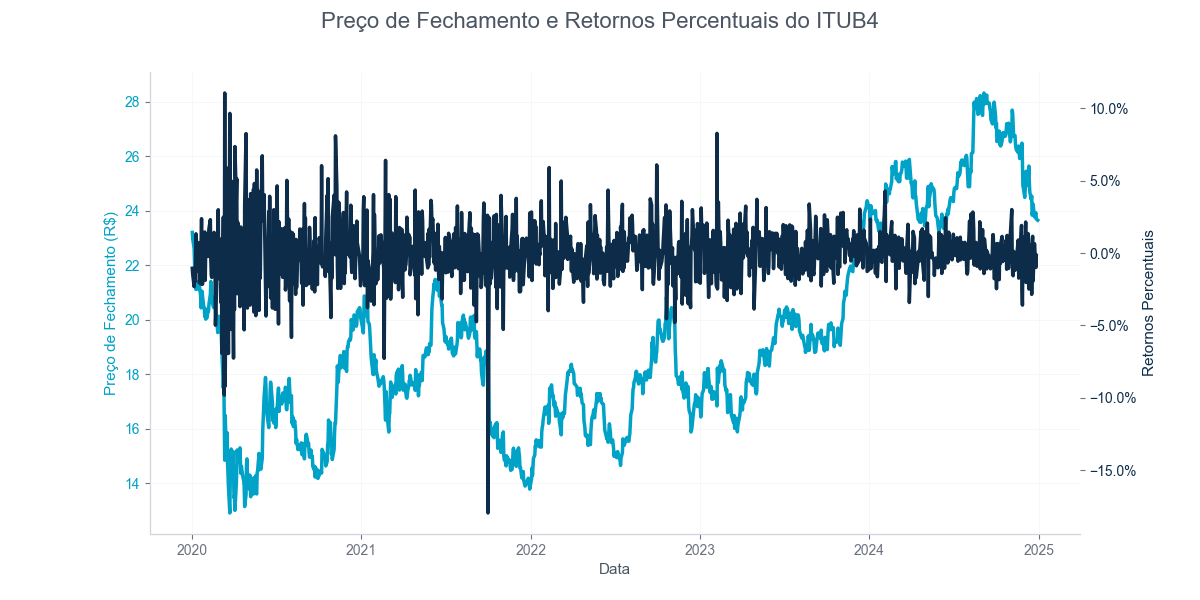

In [77]:
%matplotlib widget
import matplotlib.ticker as mtick
fig, ax1 =plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()

# gráfico de preço de fechamento
ax1.plot(df.index, df['Close'], color='C0', label='Preço de Fechamento')
ax1.set_xlabel('Data')
ax1.set_ylabel('Preço de Fechamento (R$)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# gráfico de retrno percentual
ax2.plot(df.index, df['Returns'], color='C1', label='Retornos')
ax2.set_ylabel('Retornos Percentuais', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.grid(False)
plt.suptitle('Preço de Fechamento e Retornos Percentuais do ITUB4', fontsize=16)
plt.savefig('Imagens/fechamento.png', transparent=True, bbox_inches='tight', dpi=300)


plt.show()

# **Médias Móveis**

São rastreadoras de tendências de mercado. Servem para suavizar a variação dos preços e indicam a direção predominante do ativo.

In [78]:
# média móvél exponencial de 9 e 21 dias
df['EMA_9'] = df['Close'].ewm(span=9).mean()
df['EMA_21'] = df['Close'].ewm(span=21).mean()

df['SMA_7'] = df['Close'].rolling(window=7).mean()

df.head()

Price,Close,High,Low,Open,Volume,Returns,EMA_9,EMA_21,SMA_7
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,,,,
Date,,,,,,,,,
2020-01-02,23.203928,23.203928,22.569375,22.746316,23414691,-0.010517,23.203928,23.203928,NaN
2020-01-03,22.959881,23.332072,22.850056,22.880562,28201956,-0.014882,23.068346,23.076094,NaN
2020-01-06,22.618191,22.929368,22.520568,22.911064,25259895,-0.023199,22.883856,22.908703,NaN
2020-01-07,22.093462,22.721914,22.093462,22.618189,22661019,-0.016294,22.616108,22.674899,NaN
2020-01-08,21.733473,22.459550,21.733473,22.239896,29436359,-0.019933,22.353544,22.449130,NaN


In [79]:
%matplotlib widget

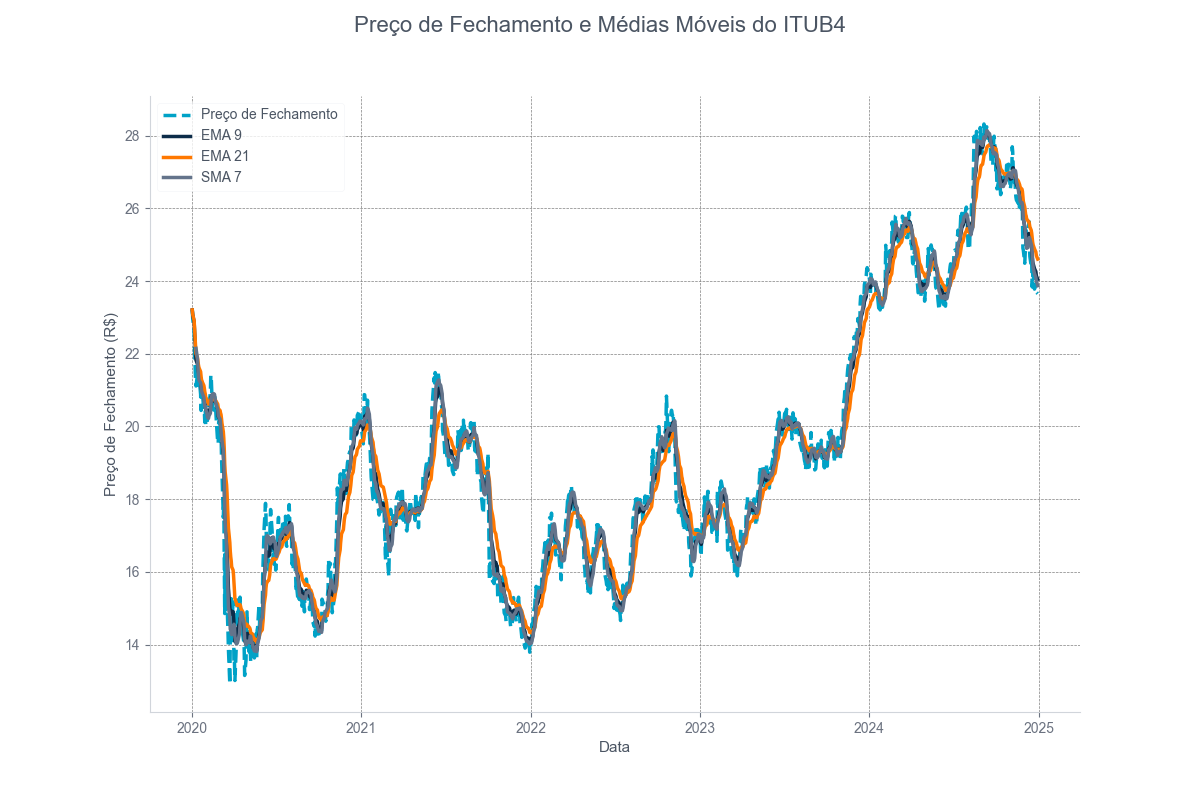

In [80]:
%matplotlib widget
fig, ax1 = plt.subplots(figsize=(12, 8))

# Preço de fechamento
ax1.plot(df.index, df['Close'], color='C0', label='Preço de Fechamento', linestyle='--')
ax1.set_xlabel('Data')
ax1.set_ylabel('Preço de Fechamento (R$)')

# Médias Móveis
ax1.plot(df.index, df['EMA_9'], color='C1', label='EMA 9')
ax1.plot(df.index, df['EMA_21'], color='C2', label='EMA 21')
ax1.plot(df.index, df['SMA_7'], color='C3', label='SMA 7')

ax1.legend(loc='best')

plt.suptitle('Preço de Fechamento e Médias Móveis do ITUB4', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')
plt.savefig('Imagens/moving_averages.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

- **Simple Moving Average (SMA):** É a média aritmética simples dos últimos $n$ dias. No caso, a SMA 7 soma os fechamentos dos últimos 7 dias e divide por 7. Ela é mais lenta para reagir.

- **Exponential Moving Average (EMA):** Dá mais peso aos preços mais recentes. Por isso, a EMA 9 e a EMA 21 no seu gráfico "colam" mais rápido no preço atual do que uma média simples faria.

**EMA_9**  flutua muito perto do preço, enquanto a **EMA_21** (laranja) é mais estável. Isso indica que médias curtas indicam o ritmo do momento (trade); médias longas indicam a saúde da tendência (investimento).

**Cruzamentos e Suportes:** No ano de 2024 o preço sobe de R$ 20 para aproximadamente R$ 28. Nesse período, sempre que o preço cai um pouco, encosta na linha laranja (EMA_21) e volta a subir. Isso mostra que as médias móveis agem como suportes para o preço. Se o preço, ultrapassar negativamente a EMA_21 de forma agressiva é um sinal de que a tendência pode ter acabado.

**O abismo de 2020 e a recuperação lateral:** No início de 2020, o preço despencou e as médias cruzam para abaixo rapidamente. Depois disso, entre 2021 e 2023 o perfil ficou lateralizado, ou seja, oscilando entorno de um valor sem evolução siginificativas ao longo do tempo. Essse período de queda e de lateralização corresponde à pandemia de COVID-19. Um período de crise em que não é seguro emprestar dinheiro, que é o principal ativo de um banco.
Isso indica que quando as médias estão todas emaranhadas e horizontais, o mercado está sem direção


# **ADX - Average Directional Index**

As médias móveis indicam a direção do preço de um ativo. O **ADX** mede a força dessa tendência (com que intensidade o preço está se movendo). O **ADX** não diz se o mercado está subindo ou descendo. Ele diz apenas se existe uma **tendência clara** ou se o mercado está **"lateralizado"**.

- **ADX abaixo de 20:** Tendência fraca ou mercado lateral (evitar operar tendências aqui).

- **ADX acima de 25:** Tendência forte começando (hora de usar suas médias móveis).

- **ADX acima de 40:** Tendência muito forte.

- **ADX acima de 50:** Tendência extrema (cuidado, pode estar perto de uma exaustão).

### **Movimento Direcional**

- **$+DM = Máxima_{hoje} - Máxima_{ontem}$** 

- **$-DM = Mínima_{ontem} - Mínima_{hoje}$**

### **Linhas direcionais**

- **$+DI = 100 * \frac{+DM}{TR}$**

- **$-DI = 100 * \frac{-DM}{TR}$**

**TR** mede a volatilidade total do ativo em período de tempo.

### **ADX**

- $ADX = Média\ Móvel(100 * \frac{|(+DI) - (-DI)|}{(+DI) + (-DI)}$)



In [81]:
from helpers import calculate_adx

df_adx = calculate_adx(data)

df_adx.head(20)

Price,Close,High,Low,Open,Volume,+DM,-DM,TR_smooth,+DM_smooth,-DM_smooth,+DI,-DI,ADX
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,,,,,,,,
Date,,,,,,,,,,,,,
2020-01-02,23.203928,23.203928,22.569375,22.746316,23414691,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,22.959881,23.332072,22.850056,22.880562,28201956,0.128144,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,22.618191,22.929368,22.520568,22.911064,25259895,0.000000,0.329488,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,22.093462,22.721914,22.093462,22.618189,22661019,0.000000,0.427106,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,21.733473,22.459550,21.733473,22.239896,29436359,0.000000,0.359989,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,21.300262,21.922615,21.062306,21.837193,54864165,0.000000,0.671167,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-10,21.111124,21.629750,21.092820,21.403996,28915972,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-13,21.391792,21.599243,21.196545,21.367386,33084393,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


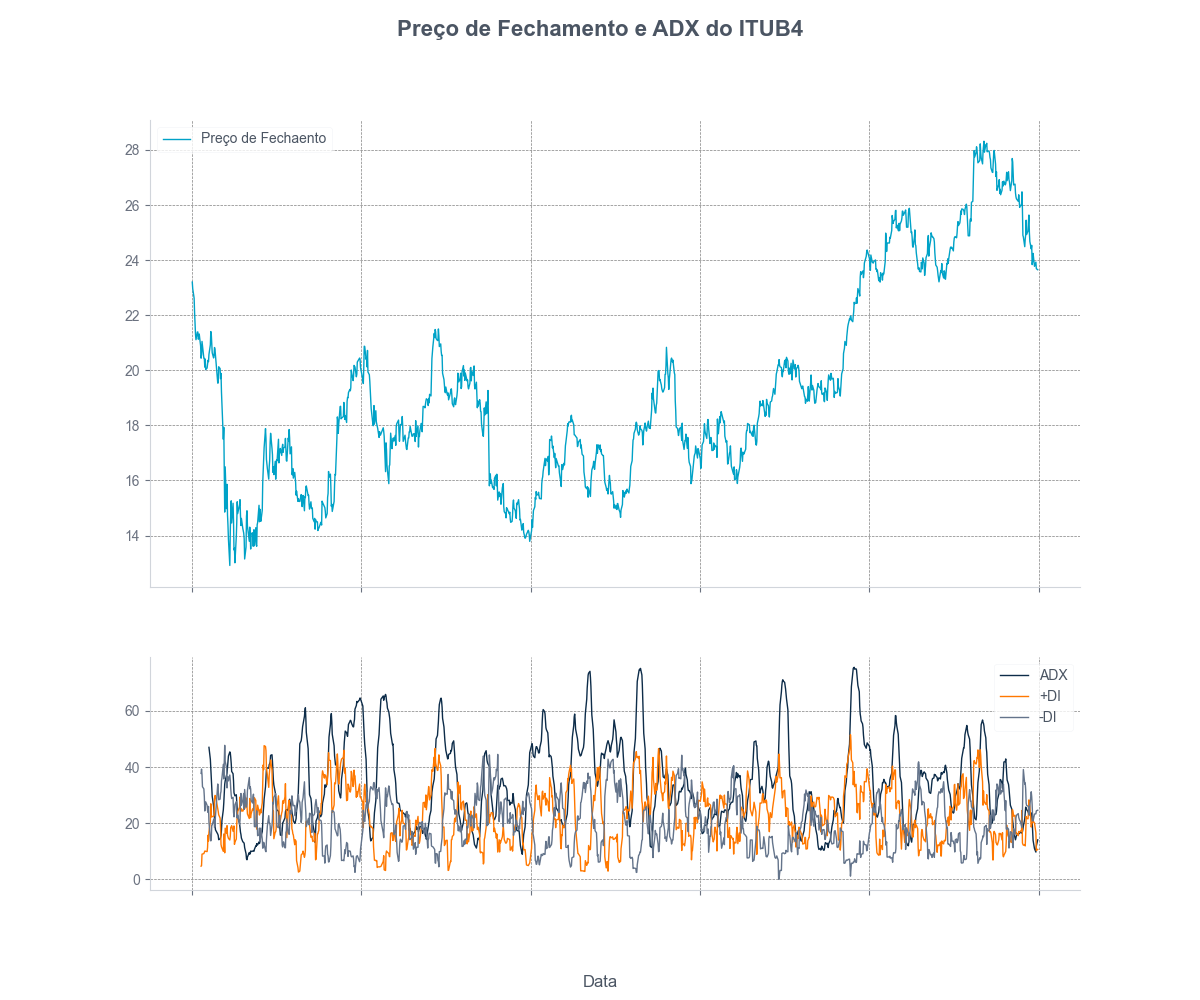

In [82]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Gráfico Preço de Fechamento
ax1.plot(df_adx.index, df_adx['Close'], color='C0', label='Preço de Fechaento', linestyle='-', linewidth=1)
ax1.set_xticklabels([])
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')
ax1.legend(loc='best')

# gráfico ADX
ax2.plot(df_adx.index, df_adx['ADX'], color='C1', label='ADX', linewidth=1)
ax2.plot(df_adx.index, df_adx['+DI'], color='C2', label='+DI', linewidth=1)
ax2.plot(df_adx.index, df_adx['-DI'], color='C3', label='-DI', linewidth=1)
ax2.legend(loc='best')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')

fig.supxlabel('Data')
plt.suptitle('Preço de Fechamento e ADX do ITUB4', fontsize=16, fontweight='bold')
plt.savefig('Imagens/adx.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()


In [83]:
from helpers import calculate_bollinger_bands

df_bollinger = calculate_bollinger_bands(data)

df_bollinger

Price,Close,High,Low,Open,Volume,EMA_20,SMA_20,STD_20,Bollinger+,Bollinger-
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,,,,,
Date,,,,,,,,,,
2020-01-02,23.203928,23.203928,22.569375,22.746316,23414691,23.203928,23.203928,NaN,NaN,NaN
2020-01-03,22.959881,23.332072,22.850056,22.880562,28201956,23.180685,23.081904,0.172567,23.427039,22.736770
2020-01-06,22.618191,22.929368,22.520568,22.911064,25259895,23.127114,22.927333,0.294222,23.515777,22.338889
2020-01-07,22.093462,22.721914,22.093462,22.618189,22661019,23.028671,22.718865,0.481193,23.681251,21.756480
2020-01-08,21.733473,22.459550,21.733473,22.239896,29436359,22.905319,22.521787,0.606514,23.734815,21.308759
...,...,...,...,...,...,...,...,...,...,...
2024-12-20,24.245445,24.260839,23.906779,23.906779,60210112,24.958684,24.967320,0.673375,26.314070,23.620571
2024-12-23,23.775928,24.099201,23.668171,23.960655,31425454,24.846041,24.856891,0.678855,26.214601,23.499180


# **Bandas de Bollinger**

É um **indicador de volatilidade**. Mede o quanto um ativo se move em relação a sua média simples formando um gráfico de bandas em que os limites são a média mais  dois desvios e a média menos dois desvios.
Quando as bandas se abrem, maior o movimento do ativo. Qunado as bandas estão mais fechadas, menor o movimento, geralmente indicando tendência de laterização.

Estatisticamente, os preços seguem uma distribuição normal, **cerca de 95% dos movimentos de preço deveriam ocorrer dentro do intervalo de bandas**. Quando o preço sai delas, está em um estado de força extrema, indicando uma nova dentência.

O mercado tem pavor de extremos. Quando o preço se afasta demais das bandas as chances de ele retornar para linha central aumentam. Esse é um bom indicador para evitar comprar ou vender quando o mercado está em extremo. Entretanto, se afastar demais, não indica necessariamente que o preço voltará para o centro, pode-se estar diante de uma tendência muito forte que pode durar por um bom tempo.


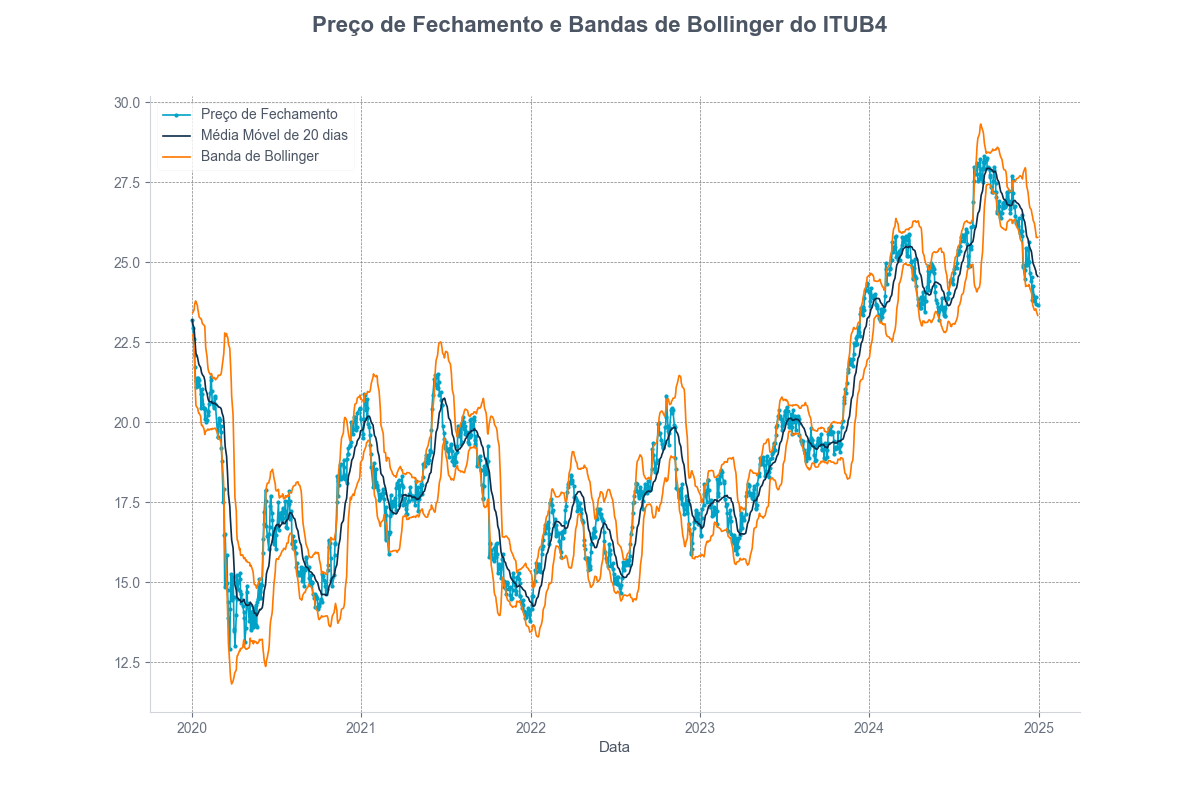

In [84]:

fig, ax = plt.subplots(figsize=(12,8))

# Preço de fechamento
ax.plot(df_bollinger.index, df_bollinger['Close'], color='C0', label='Preço de Fechamento', marker='o', linewidth=1.2, markersize=2)

# SMA e Bandas de Bollinger
ax.plot(df_bollinger.index, df_bollinger['SMA_20'], color='C1', label='Média Móvel de 20 dias', linewidth=1.2)
ax.plot(df_bollinger.index, df_bollinger['Bollinger+'], color='C2', label='Banda de Bollinger', linewidth=1.2)
ax.plot(df_bollinger.index, df_bollinger['Bollinger-'], color='C2', linewidth=1.2)

plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')
plt.xlabel('Data')
plt.legend(loc='best')
plt.suptitle('Preço de Fechamento e Bandas de Bollinger do ITUB4', fontsize=16, fontweight='bold')
plt.savefig('Imagens/bollinger_bands.png', transparent=True, bbox_inches='tight', dpi=300)


plt.show()

Pode-se notar a partir do gráfico que após períodos de estreitamento, geralmente, segue-seperíodos de novas fortes tendências, sejam de alta ou de queda. 

In [85]:
from helpers import calculate_macd

df_macd = calculate_macd(data)

df_macd

Price,Close,High,Low,Open,Volume,SMA_fast,SMA_slow,MACD,MACD_Signal,MACD_Histogram
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,,,,,
Date,,,,,,,,,,
2020-01-02,23.203928,23.203928,22.569375,22.746316,23414691,23.203928,23.203928,0.000000,0.000000,0.000000
2020-01-03,22.959881,23.332072,22.850056,22.880562,28201956,23.081904,23.081904,0.000000,0.000000,0.000000
2020-01-06,22.618191,22.929368,22.520568,22.911064,25259895,22.927333,22.927333,0.000000,0.000000,0.000000
2020-01-07,22.093462,22.721914,22.093462,22.618189,22661019,22.718865,22.718865,0.000000,0.000000,0.000000
2020-01-08,21.733473,22.459550,21.733473,22.239896,29436359,22.521787,22.521787,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2024-12-20,24.245445,24.260839,23.906779,23.906779,60210112,24.761459,25.242212,-0.480754,-0.649549,0.168796
2024-12-23,23.775928,24.099201,23.668171,23.960655,31425454,24.621981,25.144957,-0.522975,-0.625754,0.102779


#  **MACD: Moving Average Convergence Divergence**
**
O **MACD** (Convergência e Divergência de Médias Móveis) é um dos indicadores de **momentum** mais versáteis da análise técnica. Ele transforma o comportamento de médias móveis de diferentes períodos em um oscilador, permitindo visualizar não apenas a direção da tendência, mas também sua força e aceleração.

### 1. Composição Matemática
O indicador é composto por três elementos calculados dinamicamente:

* **Linha MACD (Linha Rápida):** É a diferença entre duas Médias Móveis Exponenciais (EMAs). O padrão de mercado utiliza os períodos de 12 e 26 dias.
    $$MACD = EMA_{12} - EMA_{26}$$
* **Linha de Sinal (Linha Lenta):** É uma EMA calculada sobre a própria Linha MACD, geralmente com um período de 9 dias. Ela serve para suavizar os sinais e gerar gatilhos de entrada/saída.
* **Histograma:** É a representação visual da diferença entre a Linha MACD e a Linha de Sinal.
    $$Histograma = MACD - Sinal$$


### 2. Estratégias e Interpretação

Existem três formas principais de interpretar este indicador no contexto de análise de dados:

1.  **Cruzamento de Linhas:** Quando a *Linha MACD* cruza acima da *Linha de Sinal*, o histograma torna-se positivo, indicando um aumento no momentum de compra. O inverso indica força vendedora.
2.  **Cruzamento da Linha Zero:** Funciona como um divisor de águas. Valores acima de zero indicam que a tendência de curto prazo está superando a de longo prazo (Bullish).
3.  **Divergências de Preço:** Ocorre quando o preço atinge um novo topo, mas o MACD falha em fazer o mesmo. Na engenharia, chamamos isso de perda de energia cinética do sistema, sinalizando uma possível reversão iminente.


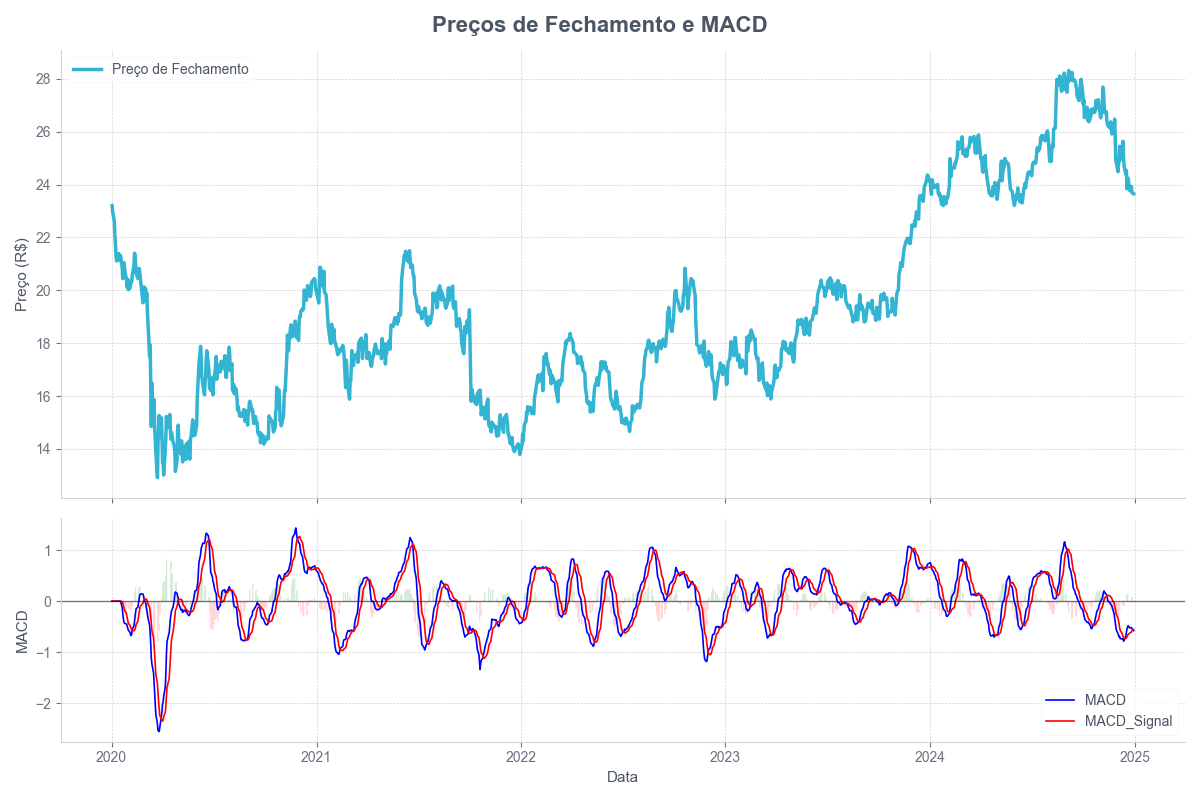

In [86]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Preço de Fechamento
ax1.plot(df_macd.index, df_macd['Close'], label='Preço de Fechamento', color='C0', alpha=0.8)
ax1.set_ylabel('Preço (R$)')
ax1.legend(loc='upper left')
ax1.grid(True, color='lightgray', linestyle='--')

# MACD

# Plotando as linhas
ax2.plot(df_macd.index, df_macd['MACD'], label='MACD', color='blue', lw=1.2)
ax2.plot(df_macd.index, df_macd['MACD_Signal'], label='MACD_Signal', color='red', lw=1.2)

# Plotando o Histograma com cores condicionais
colors = ['green' if x >= 0 else 'red' for x in df_macd['MACD_Histogram']]
ax2.bar(df_macd.index, df_macd['MACD_Histogram'], color=colors)

# Linha de equilíbrio (Zero)
ax2.axhline(0, color='black', lw=1, alpha=0.5)

ax2.set_ylabel('MACD')
ax2.set_xlabel('Data')
ax2.legend(loc='best')
ax2.grid(True, color='lightgray', linestyle='--')

plt.suptitle('Preços de Fechamento e MACD', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Imagens/macd.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# **Regressão Linear**

Agora será aplicado um modelo de ML com o algoritmo de regressão linear. O objetivo é prever o valor do ITUB4 do dia seguinte a partir das informações do dia atual.

A regressão linear será aplicada em dois datasets distintos: o primeiro será o com os dados brutos, obtidos diretamente do Yahoo Finance, o segundo será um dataset com as colunas dos indicadores estudados anteriormente.

Para o segundo dataset foram escolhidas as seguintes features: ``ADX`` que indica a direcionalidade da ação, ``EMA_9``, ``EMA_21``, ``SMA_20`` que mostram as tendências da ação de forma suavizada, ``Distance_SMA_20``, a distância da ação do média da série de 20 dias, que mostra o quão distante a ação está da média e a largura da Bollinger Band, ``Bollinger_thickness``, destacando a volatilidade da ação.

Para ambos os datasets foi aplicado a coluna `Taget` que é o valor da ação no dia seguinte que é o que se busca prever.

In [87]:
from helpers import calculate_dataframe_features

# Criando o dataframe com novas features a partir dos dados do Yahoo Finance
df_new_features = calculate_dataframe_features(data)

df_new_features

Price,ADX,EMA_9,EMA_21,SMA_20,Distance_SMA_20,Bollinger_thickness,Target
Ticker,,,,,,,
Date,,,,,,,
2020-02-07,47.025224,20.403539,20.611892,20.661938,-0.084445,0.453307,20.925442
2020-02-10,42.743525,20.508122,20.642520,20.638621,0.286821,0.669262,21.407681
2020-02-11,39.511777,20.688312,20.716760,20.639415,0.768265,0.951778,21.322222
2020-02-12,36.656604,20.815251,20.775148,20.649055,0.673167,0.883530,20.992586
2020-02-13,33.078113,20.850753,20.796002,20.640077,0.352509,0.705298,20.638536
...,...,...,...,...,...,...,...
2024-12-19,17.221786,24.542277,25.071053,25.054655,-1.086298,0.105232,24.245445
2024-12-20,13.893163,24.482911,24.995997,24.967320,-0.721875,0.231993,23.775928


In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [89]:
df1 = data.copy()
df1['Target'] = df1['Close'].shift(-1)
df1.dropna(inplace=True)

In [90]:
# Separando as features e o target
X1 = df1.drop(columns='Target')
y1 = df1['Target']

# Dividindo a base em dados de treino e de teste
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [91]:
# Aplicando o modelo de regressão linear e treinando
regressor = LinearRegression()
regressor.fit(X1, y1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
# Avaliando o modelo na base de treino
regressor.score(X1_train, y1_train)

0.9909472401342141

In [93]:
# Avaliando o modelo na base de teste
regressor.score(X1_test, y1_test)

0.9898457438203931

In [94]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [95]:
# Usando o modelo para fazer previsão de preços na base de teste
y1_pred = regressor.predict(X1_test)

In [96]:
# Avaliando as métricas de desempenho 
r2_score(y1_test, y1_pred)

0.9898457438203931

In [97]:
mean_absolute_error(y1_test, y1_pred)

0.2689671895430011

Agora com as features de tendência criadas 

In [98]:
X2 = df_new_features.drop(columns='Target')
y2 = df_new_features['Target']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [99]:
regressor2 = LinearRegression()
regressor2.fit(X2, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [100]:
y2_pred = regressor2.predict(X2_test)

In [101]:
r2_score(y2_test, y2_pred)

0.9914756313496258

In [102]:
mean_absolute_error(y2_test, y2_pred)

0.24755186122680858

Agora vamos testar com uma base de dados que não foi usada para treinar os modelos e ver qual apresenta o melhor desempenho, analisando a previsão do dia 01/12/2025 até os dias de hoje.

In [103]:
df_2025_2026 = yf.download("ITUB4.SA", start='2025-12-01', end ='2026-04-17')

[*********************100%***********************]  1 of 1 completed


In [104]:
df_prova1 = df_2025_2026.copy()
df_prova1['Target'] = df_prova1['Close'].shift(-1)
df_prova1.dropna(inplace=True)


In [105]:
df_prova1.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 91 entries, 2025-12-01 to 2026-04-15
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, ITUB4.SA)   91 non-null     float64
 1   (High, ITUB4.SA)    91 non-null     float64
 2   (Low, ITUB4.SA)     91 non-null     float64
 3   (Open, ITUB4.SA)    91 non-null     float64
 4   (Volume, ITUB4.SA)  91 non-null     int64  
 5   (Target, )          91 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 5.0 KB


In [106]:
X_prova1 = df_prova1.drop(columns='Target')
y_prova1 = df_prova1['Target']


In [107]:
yp1_pred = regressor.predict(X_prova1)

In [108]:
r2_score(y_prova1, yp1_pred)

0.9381694816841537

In [109]:
mean_absolute_error(y_prova1, yp1_pred)

0.6713159511591312

Agora como o modelo das novas features

In [110]:
df_prova2 = calculate_dataframe_features(df_2025_2026)
df_prova2.head()

Price,ADX,EMA_9,EMA_21,SMA_20,Distance_SMA_20,Bollinger_thickness,Target
Ticker,,,,,,,
Date,,,,,,,
2026-01-12,26.198312,39.103902,38.793000,38.574294,0.544911,0.705756,38.802212
2026-01-13,28.818052,39.043447,38.793900,38.618698,0.183514,0.571125,39.228168
2026-01-14,29.825890,39.080448,38.836035,38.685841,0.542327,0.713687,39.564980
2026-01-15,32.009809,39.177475,38.906331,38.753002,0.811978,0.810587,39.238079
2026-01-16,32.522165,39.189608,38.938148,38.774978,0.463101,0.674749,39.178642


In [111]:
X_prova2 = df_prova2.drop(columns='Target')
y_prova2 = df_prova2['Target']

In [112]:
yp2_pred = regressor2.predict(X_prova2)

In [113]:
r2_score(y_prova2, yp2_pred)

0.8908198509272969

In [114]:
mean_absolute_error(y_prova2, yp2_pred)

0.693573096237631

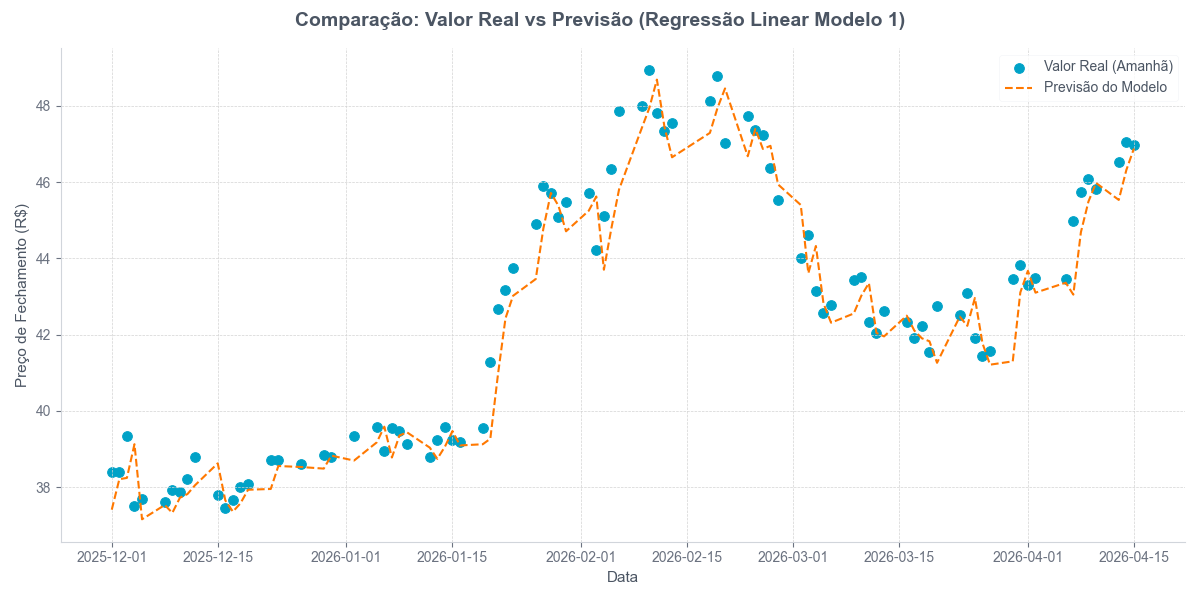

In [127]:
# Gráfico comparativo entre os valores reais e as previsões do modelo para a base de prova

# Criar um DataFrame temporário para organizar os dados por data
df_comparacao = pd.DataFrame({
    'Real': y_prova1,
    'Previsao': yp1_pred
}, index=X_prova1.index).sort_index() # Ordenar por data

# Plotar o gráfico
plt.figure(figsize=(12, 6))

plt.scatter(df_comparacao.index, df_comparacao['Real'], label='Valor Real (Amanhã)', color='C0', linewidth=0.7)
plt.plot(df_comparacao.index, df_comparacao['Previsao'], label='Previsão do Modelo', color='C2', linestyle='--', linewidth=1.5)


plt.suptitle('Comparação: Valor Real vs Previsão (Regressão Linear Modelo 1)', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (R$)')
plt.legend(loc='best')
plt.grid(True, color='lightgray', linestyle='--')

plt.tight_layout()

plt.savefig('Imagens/real_vs_previsao_M1.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

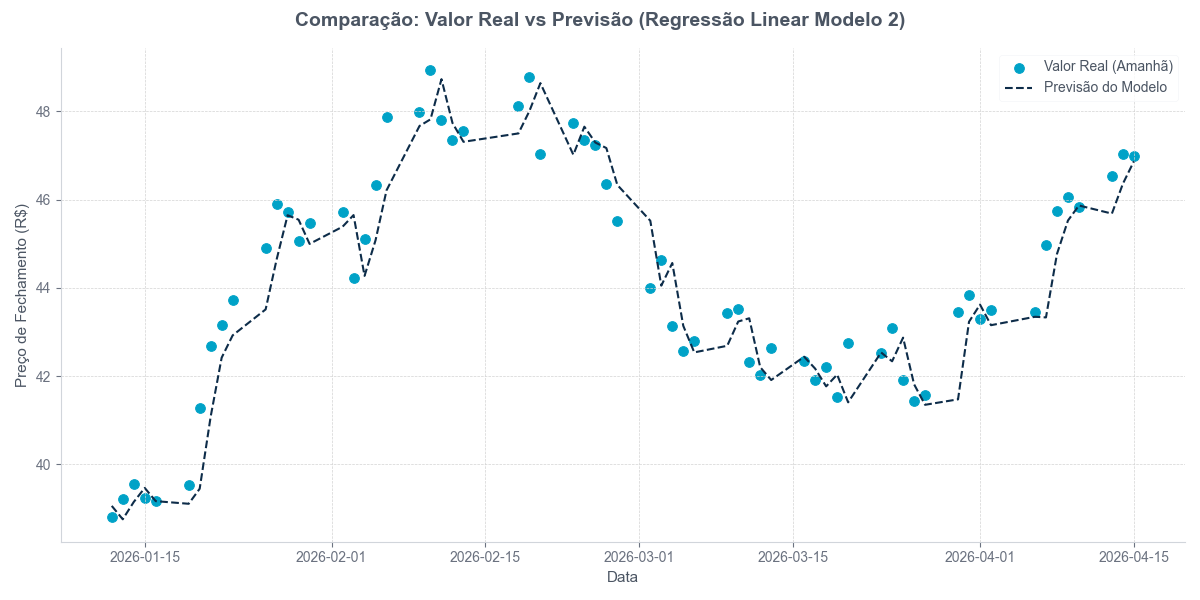

In [116]:
# Gráfico comparativo entre os valores reais e as previsões do modelo para a base de prova

# Criar um DataFrame temporário para organizar os dados por data
df_comparacao = pd.DataFrame({
    'Real': y_prova2,
    'Previsao': yp2_pred
}, index=X_prova2.index).sort_index() # Ordenar por data

# Plotar o gráfico
plt.figure(figsize=(12, 6))

plt.scatter(df_comparacao.index, df_comparacao['Real'], label='Valor Real (Amanhã)', color='C0', linewidth=0.7)
plt.plot(df_comparacao.index, df_comparacao['Previsao'], label='Previsão do Modelo', color='C1', linestyle='--', linewidth=1.5)


plt.suptitle('Comparação: Valor Real vs Previsão (Regressão Linear Modelo 2)', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (R$)')
plt.legend(loc='best')
plt.grid(True, color='lightgray', linestyle='--')

plt.tight_layout()

plt.savefig('Imagens/real_vs_previsao_M2.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

O modelo 1, com os dados brutos obtidos do Yahoo Finance, possui uma precisão superior ao modelo 2, que usa os indicadores de mercado. Porém, a partir da análise gráfica, pode-se perceber que o modelo 1 está muito ajustado aos dados, indicando que ele pode ter aprendido a simplesmente a "chutar" valores próximos do preço atual. O modelo 2 não apresenta diretamente o preço de fechamento do dia, mas sim indicadores de tendência, força e volatilidade, sendo assim, mais robusto e menos suscetível a "vicios" de treinamento. 

Ainda analisando graficamente, é possível ver que o modelo 2 é muito mais conservador em quedas e altas, ou seja, em momentos de alta ele prevê um preço menor do que o esperado e em momentos de baixa valores maiores, isso se deve provavelmente a influência das médias móveis, sendo assim, vale analisar as features com maior peso no modelo 2.

In [117]:
X2 = df_new_features.drop(columns='Target')
y2 = df_new_features['Target']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [118]:
coefs = pd.DataFrame(regressor2.coef_, X2.columns, columns=['Coeficiente']).sort_values(by='Coeficiente')

coefs

,,Coeficiente
Price,Ticker,
EMA_21,,-0.012199
ADX,,0.000263
Bollinger_thickness,,0.060914
EMA_9,,0.168661
SMA_20,,0.838455
Distance_SMA_20,,0.892905


c:\Users\paulo\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\plotting\_matplotlib\core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=self.figsize)


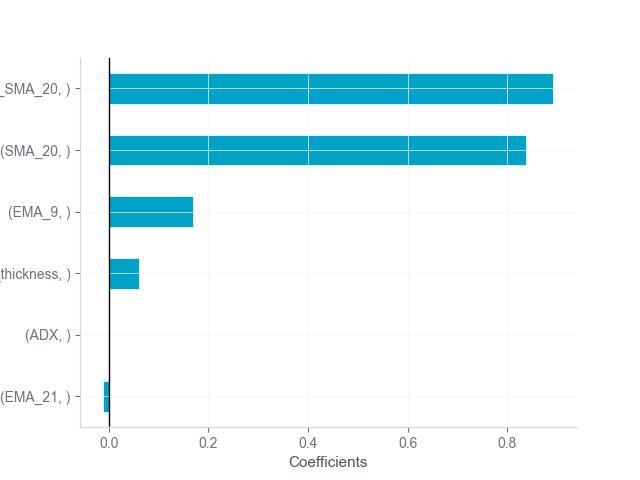

In [ ]:
coefs.plot.barh()

plt.axvline(0, color='black', lw=1)
plt.xlabel('Coefficients')
plt.gca().get_legend().remove()


In [120]:
df_prova2.head()

Price,ADX,EMA_9,EMA_21,SMA_20,Distance_SMA_20,Bollinger_thickness,Target
Ticker,,,,,,,
Date,,,,,,,
2026-01-12,26.198312,39.103902,38.793000,38.574294,0.544911,0.705756,38.802212
2026-01-13,28.818052,39.043447,38.793900,38.618698,0.183514,0.571125,39.228168
2026-01-14,29.825890,39.080448,38.836035,38.685841,0.542327,0.713687,39.564980
2026-01-15,32.009809,39.177475,38.906331,38.753002,0.811978,0.810587,39.238079
2026-01-16,32.522165,39.189608,38.938148,38.774978,0.463101,0.674749,39.178642


In [121]:
df_prova2.describe()

Price,ADX,EMA_9,EMA_21,SMA_20,Distance_SMA_20,Bollinger_thickness,Target
Ticker,,,,,,,
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,36.966844,43.698739,43.236009,43.248885,0.838528,0.638160,44.208348
std,11.847872,2.467112,2.235670,2.594000,2.612324,0.363871,2.615505
min,16.114495,39.043447,38.793000,38.574294,-4.009234,-0.046549,38.802212
25%,28.818052,42.495968,42.568543,41.814497,-1.137771,0.260603,42.522213
50%,33.777922,43.729887,43.511692,43.205508,0.811978,0.726550,43.830002
75%,46.882985,45.417781,44.850951,45.462428,3.054242,0.873268,46.329552
max,58.200155,47.569028,46.320066,46.887654,5.361590,1.325269,48.925983


Como suspeitado, as variáveis de maior peso estão relacionadas às médias móveis, entretanto as variáveis ``Distance_SMA_20`` e ``Bollinger_thickness`` não estão na mesma ordem de grandeza das demais, logo, é possível fazer uma noralização para que possamos avaliar melhor a relaão entre as variáveis e o target.

In [122]:
from sklearn.preprocessing import StandardScaler

# Supondo que X_train e X_test já existam
scaler = StandardScaler()

# IMPORTANTE: ajuste o scaler apenas nos dados de TREINO para evitar vazamento de dados
X_train_scaled = scaler.fit_transform(X2_train)

# Use o mesmo scaler para transformar os dados de TESTE
X_test_scaled = scaler.transform(X_prova2)

In [123]:
regressor2_1 = LinearRegression()
regressor2_1.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
coefs2 = pd.DataFrame(regressor2_1.coef_, X2.columns, columns=['Coeficiente']).sort_values(by='Coeficiente')

coefs2

,,Coeficiente
Price,Ticker,
ADX,,0.000787
EMA_21,,0.007203
Bollinger_thickness,,0.102252
EMA_9,,0.151996
SMA_20,,0.837776
Distance_SMA_20,,0.882755


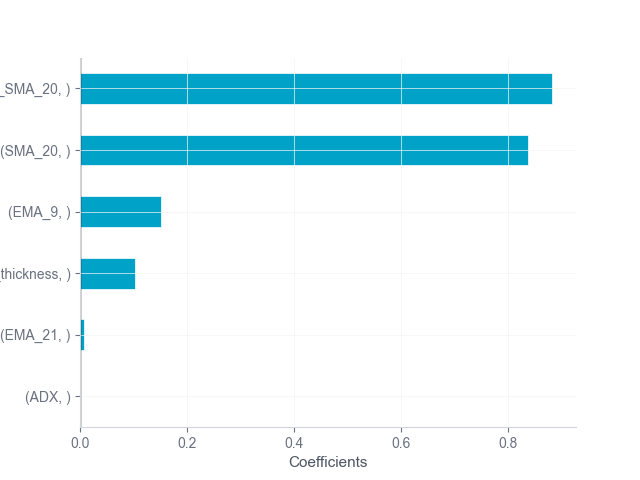

In [125]:
coefs2.plot.barh()

plt.axvline(0, color='black', lw=1)
plt.xlabel('Coefficients')
plt.gca().get_legend().remove()

A normalização dos daos interfere muito pouco na ordem de classificação das features, indicando que essa alteração implica em pouca variação marginal no modelo.

In [126]:
import joblib

caminho_modelo = r'C:\Users\paulo\OneDrive\Documentos\Projeto Yahoo Finance\modelo_itub4_regressao.pkl'
modelo = joblib.load(caminho_modelo)